<a href="https://colab.research.google.com/github/BeanQueso/dsrp/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ai_digital_media = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/AI%20and%20Digital%20Media/Global_AI_Content_Impact_Dataset.csv")

first_valid_year = {
    'Bard': 2023,
    'ChatGPT': 2022,
    'Claude': 2023,
    'DALL-E': 2021,
    'Midjourney': 2022,
    'Stable Diffusion': 2022,
    'Synthesia': 2020
}

mismatch_count = 0
check_list = []

for index, row in ai_digital_media.iterrows():
    tool = row['Top AI Tools Used']
    year = row['Year']

    if year < first_valid_year[tool]:
        mismatch_count += 1
        check_list.append(row)

print(mismatch_count)

72


In [3]:
ai_digital_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [4]:
ai_digital_media.drop_duplicates(inplace=True)
ai_digital_media.reset_index(drop=True, inplace=True)
ai_digital_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

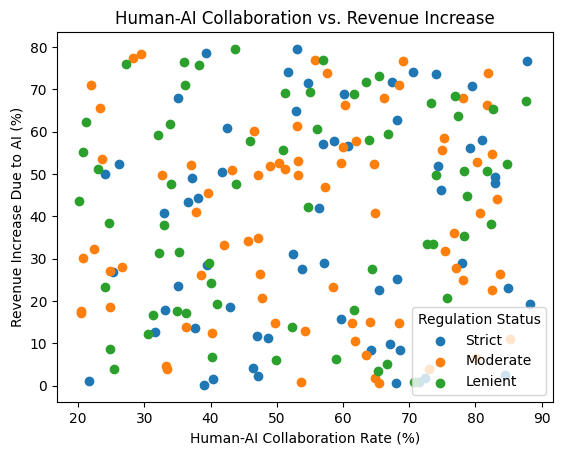

In [5]:
for status in ai_digital_media['Regulation Status'].unique():
    data = ai_digital_media[
        ai_digital_media['Regulation Status'] == status
    ]

    plt.scatter(
        data['Human-AI Collaboration Rate (%)'],
        data['Revenue Increase Due to AI (%)'],
        label=status
    )

plt.title('Human-AI Collaboration vs. Revenue Increase')
plt.xlabel('Human-AI Collaboration Rate (%)')
plt.ylabel('Revenue Increase Due to AI (%)')
plt.legend(title='Regulation Status')
plt.show()

In [6]:
repeated_groups = ai_digital_media[ai_digital_media.duplicated(subset=['Country', 'Year', 'Industry'], keep=False)].sort_values(['Country', 'Year', 'Industry'])

repeated_groups

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
67,China,2020,Manufacturing,45.27,82.47,12.07,57.15,57.03,Midjourney,Strict,42.57,39.35
80,China,2020,Manufacturing,72.88,1.55,47.77,76.86,55.78,Midjourney,Moderate,57.09,12.10
137,China,2020,Manufacturing,93.49,16.96,20.47,26.27,83.71,ChatGPT,Moderate,70.17,45.17
128,China,2020,Media,43.22,52.80,43.20,51.15,51.23,Bard,Moderate,60.89,33.40
166,China,2020,Media,35.22,84.15,20.44,73.08,65.49,Synthesia,Lenient,48.02,22.55
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
87,China,2025,Legal,87.73,44.74,42.89,78.50,39.34,DALL-E,Strict,78.54,32.72
46,France,2020,Media,20.47,1.61,2.43,31.04,52.49,Stable Diffusion,Strict,35.80,24.29
170,France,2020,Media,55.19,41.06,29.26,51.90,49.04,ChatGPT,Moderate,50.12,46.08
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
